# Analysis Cross-Comparison & Calculated Similarities

Naive baseline approach: cross-compares every reference word against every hypothesis word
(exhaustive O(n×m) cross-comparison without 1:1 alignment constraint).


## Imports


In [1]:
import sys
import importlib
from pathlib import Path

# locate project root by walking up until requirements.txt is found
_anchor = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (_anchor, *_anchor.parents) if (p / "requirements.txt").exists())
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "domain"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "utils"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments" / "cross_comparison"))

import pandas as pd

import preprocessing
import word_similarity_calculator
import plot_helpers
importlib.reload(preprocessing)
importlib.reload(word_similarity_calculator)
importlib.reload(plot_helpers)

from cross_comparison import generate_cross_comparison_df
from word_similarity_calculator import WordSimilarityCalculator
from preprocessing import clean_word
from plot_helpers import plot_similarity_distribution


In [2]:
ANALYSIS_DIR = PROJECT_ROOT / "experiments" / "stt-analysis" / "transcripts"

DIALECT_AWARE_TRANSCRIPT = ANALYSIS_DIR / "fhnw_dialect-aware.tsv"
DIALECT_IGNORANT_TRANSCRIPT = ANALYSIS_DIR / "whsiper-largev2_dialect-ignorant.tsv"


## Load data


In [3]:
df_dat = pd.read_csv(DIALECT_AWARE_TRANSCRIPT, sep="\t", encoding="utf-8-sig")
df_dit = pd.read_csv(DIALECT_IGNORANT_TRANSCRIPT, sep="\t", encoding="utf-8-sig")

df = pd.merge(
    df_dat[["path", "sentence", "transcript"]].rename(columns={"transcript": "DAT"}),
    df_dit[["path", "transcript"]].rename(columns={"transcript": "DIT"}),
    on="path",
    how="inner",
)
df.head()

,path,sentence,DAT,DIT
0,clips/300bb931-79ae-40ec-b989-3efd5e83f4c2/83c...,Insgesamt habe ich einige Hunderttausend Frank...,Insgesamt habe ich einige Hunderttausend Frank...,Insgesamt habe ich einige hunderttausend Frank...
1,clips/6e084270-8d26-43d9-ba69-5e8ee793ab8c/dca...,Welche Rolle hatte Rosenberg während des Holoc...,Welche Rolle hatte Rosenberg während des Holoc...,Welche Rolle hatte Rausenberg während des Holo...
2,clips/6858a37b-edd0-4fdf-871c-96d3b1bd3e21/82f...,Das ist angesichts aller schlechten Optionen d...,Das ist angesichts aller schlechten Optionen d...,Das ist angesichts aller schlechten Optionen d...
3,clips/c4c03e6f-50a2-4d24-ae88-caf3032798fa/a21...,Ebenfalls keinen Sieg durfte die AC Milan feiern.,Ebenfalls keinen Sieg durfte AC Milan feiern.,Ebenfalls kein Sieg durfte AC Milan feiern.
4,clips/f877ee50-af2b-423b-bdda-0cc406032c45/4e5...,Viele Fussballfans haben die Alte Reithalle un...,Viele Fussballfans haben die alte Reithalle un...,Viele Fussballfans haben die Alt-Rheintaler un...


## Max Word & Sentence Length


In [4]:
all_words = (
    df["sentence"].dropna().str.split().explode().tolist()
    + df["DIT"].dropna().str.split().explode().tolist()
    + df["DAT"].dropna().str.split().explode().tolist()
)
all_sentences = pd.concat(
    [df["sentence"].dropna(), df["DIT"].dropna(), df["DAT"].dropna()]
)

global_max_word_length = max(len(clean_word(w)) for w in all_words)
global_max_sentence_length = max(len(str(s).split()) for s in all_sentences)

print(f"Global max word length: {global_max_word_length}")
print(f"Global max sentence length: {global_max_sentence_length}")

Global max word length: 22
Global max sentence length: 20


## Cross-Comparison

Each function call compares every reference word against every hypothesis word for a single sentence pair.
Called separately for DIT and DAT.


In [5]:
calculator = WordSimilarityCalculator(
    sent_len=global_max_sentence_length,
    alpha=0.4,
    lambda_=0.7,
    use_global_lexical_normalization=True,
    max_word_len=global_max_word_length,
)

dit_frames = []
dat_frames = []

for idx, row in df.iterrows():
    ref_words = str(row["sentence"]).split()
    dit_words = str(row["DIT"]).split()
    dat_words = str(row["DAT"]).split()

    dit_df = generate_cross_comparison_df(ref_words, dit_words, calculator)
    dit_df["clip_id"] = row["path"]
    dit_frames.append(dit_df)

    dat_df = generate_cross_comparison_df(ref_words, dat_words, calculator)
    dat_df["clip_id"] = row["path"]
    dat_frames.append(dat_df)

cross_comparison_dit = pd.concat(dit_frames, ignore_index=True)
cross_comparison_dat = pd.concat(dat_frames, ignore_index=True)

print(f"DIT pairs: {len(cross_comparison_dit)}")
print(f"DAT pairs: {len(cross_comparison_dat)}")


DIT pairs: 7704
DAT pairs: 7575


### Summary statistics


In [6]:
similarity_cols = ["word_similarity", "position_similarity", "similarity_weighted"]

print("=== DIT ===")
display(cross_comparison_dit[similarity_cols].describe().round(5))

print("\n=== DAT ===")
display(cross_comparison_dat[similarity_cols].describe().round(5))

=== DIT ===


,word_similarity,position_similarity,similarity_weighted
count,7704.00000,7704.00000,7704.00000
mean,0.74290,0.82496,0.79213
std,0.15453,0.14509,0.11799
min,0.04545,0.00000,0.21818
25%,0.63636,0.73684,0.72344
50%,0.77273,0.84211,0.80096
75%,0.86364,0.94737,0.86411
max,1.00000,1.00000,1.00000



=== DAT ===


,word_similarity,position_similarity,similarity_weighted
count,7575.00000,7575.00000,7575.00000
mean,0.74436,0.82758,0.79430
std,0.15620,0.14341,0.11825
min,0.04545,0.00000,0.21818
25%,0.63636,0.73684,0.72440
50%,0.77273,0.84211,0.80478
75%,0.86364,0.94737,0.86411
max,1.00000,1.00000,1.00000


### Single Clip Example (index 2)

Exhaustive mapping of every reference word against every hypothesis word for a single clip.


In [7]:
clip_index = 7
example_clip_id = df.iloc[clip_index]["path"]

print(f"Clip ID: {example_clip_id}")
print(f"Reference: {df.iloc[clip_index]['sentence']}")
print(f"DIT:       {df.iloc[clip_index]['DIT']}")
print(f"DAT:       {df.iloc[clip_index]['DAT']}")


Clip ID: clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d6d893ce9bdb45890219ae0b5196308848694696613c2b56214288990d487b.flac
Reference: Gemäss jetziger Kenntnis wurde niemand verletzt.
DIT:       Gemäss jetziger Erkenntnis ist niemand verletzt worden.
DAT:       Gemäss jetzigen Erkenntnissen wurde niemand verletzt.


In [8]:
example_dit = cross_comparison_dit.loc[
    cross_comparison_dit["clip_id"] == example_clip_id
].sort_values(["ref_index", "hyp_index"]).reset_index(drop=True)
example_dit

,ref_index,hyp_index,ref_word,hyp_word,word_similarity,position_similarity,similarity_weighted,clip_id
0,0,0,gemäss,gemäss,1.000000,1.000000,1.000000,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
1,0,1,gemäss,jetziger,0.681818,0.947368,0.841148,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
2,0,2,gemäss,erkenntnis,0.636364,0.894737,0.791388,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
3,0,3,gemäss,ist,0.772727,0.842105,0.814354,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
4,0,4,gemäss,niemand,0.772727,0.789474,0.782775,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
5,0,5,gemäss,verletzt,0.681818,0.736842,0.714833,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
6,0,6,gemäss,worden,0.727273,0.684211,0.701435,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
7,1,0,jetziger,gemäss,0.681818,0.947368,0.841148,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
8,1,1,jetziger,jetziger,1.000000,1.000000,1.000000,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
9,1,2,jetziger,erkenntnis,0.590909,0.947368,0.804785,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...


In [9]:
example_dat = cross_comparison_dat.loc[
    cross_comparison_dat["clip_id"] == example_clip_id
].sort_values(["ref_index", "hyp_index"]).reset_index(drop=True)
example_dat

,ref_index,hyp_index,ref_word,hyp_word,word_similarity,position_similarity,similarity_weighted,clip_id
0,0,0,gemäss,gemäss,1.000000,1.000000,1.000000,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
1,0,1,gemäss,jetzigen,0.681818,0.947368,0.841148,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
2,0,2,gemäss,erkenntnissen,0.545455,0.894737,0.755024,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
3,0,3,gemäss,wurde,0.727273,0.842105,0.796172,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
4,0,4,gemäss,niemand,0.772727,0.789474,0.782775,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
5,0,5,gemäss,verletzt,0.681818,0.736842,0.714833,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
6,1,0,jetziger,gemäss,0.681818,0.947368,0.841148,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
7,1,1,jetziger,jetzigen,0.954545,1.000000,0.981818,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
8,1,2,jetziger,erkenntnissen,0.590909,0.947368,0.804785,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...
9,1,3,jetziger,wurde,0.681818,0.894737,0.809569,clips/f877ee50-af2b-423b-bdda-0cc406032c45/63d...


### Similarity distributions


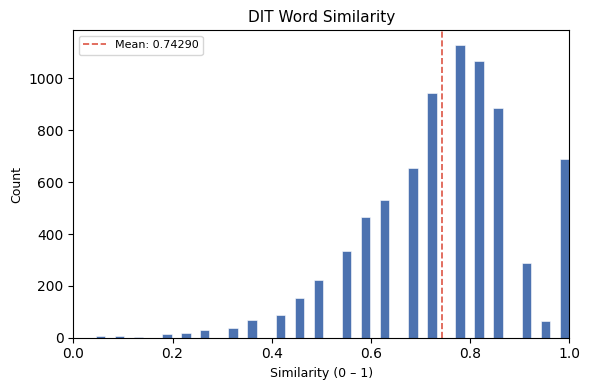

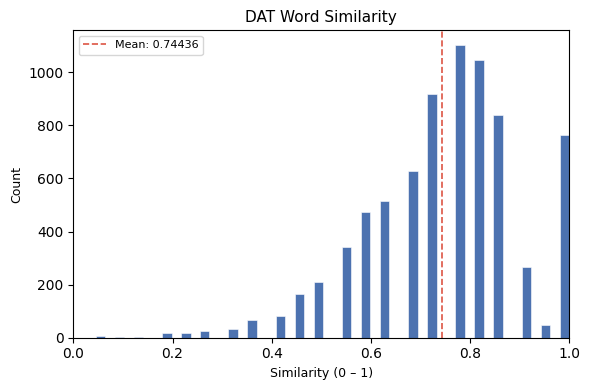

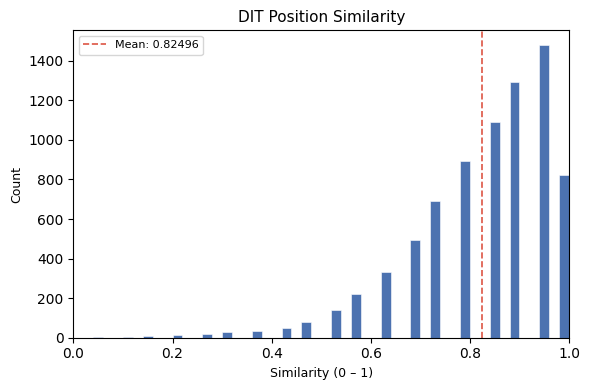

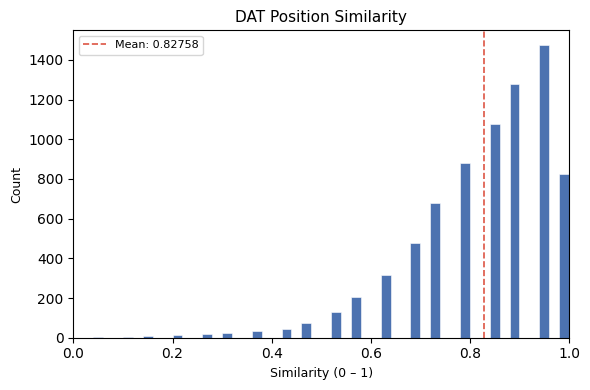

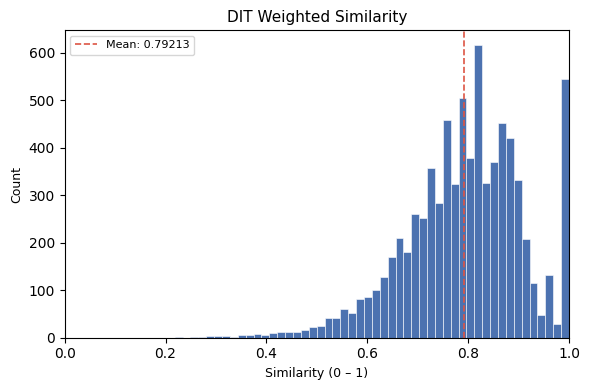

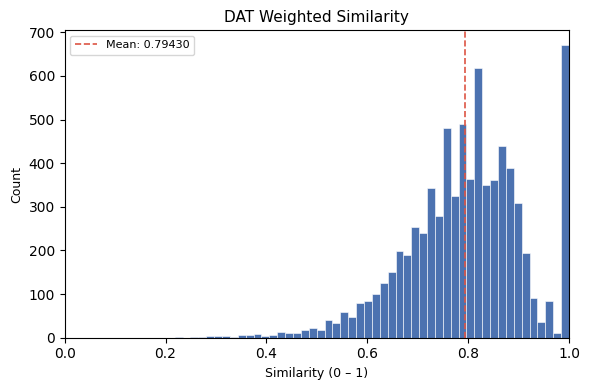

In [10]:
plot_similarity_distribution(cross_comparison_dit["word_similarity"], "DIT Word Similarity")
plot_similarity_distribution(cross_comparison_dat["word_similarity"], "DAT Word Similarity")
plot_similarity_distribution(cross_comparison_dit["position_similarity"], "DIT Position Similarity")
plot_similarity_distribution(cross_comparison_dat["position_similarity"], "DAT Position Similarity")
plot_similarity_distribution(cross_comparison_dit["similarity_weighted"], "DIT Weighted Similarity")
plot_similarity_distribution(cross_comparison_dat["similarity_weighted"], "DAT Weighted Similarity")
